# Data Fetching for Finance and Macro Analysis

This notebook explains what an API is and shows how to fetch free financial and macroeconomic data online. It focuses on simple, reproducible examples that students can reuse in their own projects.

We will cover:
- what an API does
- how to fetch stock data with free public endpoints
- how to pull macro data from FRED
- how to use the World Bank API for country-level indicators
- how to organize downloaded data for later analysis

## 1. What is an API?

An API, or Application Programming Interface, is a contract for how one program asks another program for data or services.

For data work, an API usually means:
- you send a request to a URL
- the server returns data in JSON, CSV, XML, or HTML
- your code parses the response into a DataFrame or dictionary

Why APIs matter for finance and macro data:
- the data is updated automatically
- the format is usually consistent
- you can reproduce a workflow instead of copying values manually

In [5]:
from io import StringIO
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")

try:
    import yfinance as yf
except ImportError:
    yf = None


def fetch_csv(url):
    response = requests.get(url, timeout=30, headers={"User-Agent": "Mozilla/5.0"})
    response.raise_for_status()
    lines = response.text.strip().splitlines()
    header_index = next(
        (index for index, line in enumerate(lines) if line.split(",")[0].strip().upper() in {"DATE", "OBSERVATION_DATE"}),
        None,
    )
    if header_index is None:
        raise ValueError(f"Could not find a CSV header in response from {url}")
    csv_text = "\n".join(lines[header_index:])
    return pd.read_csv(StringIO(csv_text))


def fetch_json(url):
    response = requests.get(url, timeout=30, headers={"User-Agent": "Mozilla/5.0"})
    response.raise_for_status()
    return response.json()


print("Notebook ready. If yfinance is missing, the notebook will still run using free public APIs below.")

Notebook ready. If yfinance is missing, the notebook will still run using free public APIs below.


## 2. Financial data sources

A common finance workflow starts with market data. The most widely used convenience library is `yfinance`, which wraps Yahoo Finance data in a Python-friendly interface.

This notebook uses the public Yahoo Finance chart endpoint directly so the example is easy to inspect and does not depend on a helper library.

Typical uses:
- price history for stocks and ETFs
- volume and return calculations
- simple comparisons across assets

In [7]:
def fetch_yahoo_chart(symbol, range_="6mo", interval="1d"):
    url = (
        f"https://query1.finance.yahoo.com/v8/finance/chart/{symbol}"
        f"?range={range_}&interval={interval}&includePrePost=false&events=div%2Csplits"
    )
    payload = fetch_json(url)
    result = payload["chart"]["result"][0]
    timestamps = result["timestamp"]
    quote = result["indicators"]["quote"][0]

    frame = pd.DataFrame(
        {
            "Date": pd.to_datetime(timestamps, unit="s"),
            "Open": quote.get("open"),
            "High": quote.get("high"),
            "Low": quote.get("low"),
            "Close": quote.get("close"),
            "Volume": quote.get("volume"),
        }
    )
    frame["Ticker"] = symbol
    return frame.dropna(subset=["Close"])


stock_frames = [fetch_yahoo_chart("AAPL"), fetch_yahoo_chart("MSFT")]
stocks = pd.concat(stock_frames, ignore_index=True).sort_values(["Ticker", "Date"])

display(stocks.head())
display(stocks.groupby("Ticker")[ ["Open", "High", "Low", "Close", "Volume"] ].agg(["min", "max", "mean"]).round(2))

,Date,Open,High,Low,Close,Volume,Ticker
0,2025-11-24 14:30:00,270.899994,277.000000,270.899994,275.920013,65585800,AAPL
1,2025-11-25 14:30:00,275.269989,280.380005,275.250000,276.970001,46914200,AAPL
2,2025-11-26 14:30:00,276.959991,279.529999,276.630005,277.549988,33431400,AAPL
3,2025-11-28 14:30:00,277.260010,279.000000,275.989990,278.850006,20135600,AAPL
4,2025-12-01 14:30:00,278.010010,283.420013,276.140015,283.100006,46587700,AAPL


Open                    High                    Low                  \
           min     max    mean     min    max    mean     min     max    mean   
Ticker                                                                          
AAPL    247.32  306.12  268.55  249.20  311.4  271.32  243.42  305.84  266.02   
MSFT    361.90  489.10  428.88  362.45  493.5  433.14  356.28  488.50  424.33   

         Close                    Volume                          
           min     max    mean       min        max         mean  
Ticker                                                            
AAPL    246.63  308.82  268.78  17910600  144632000  45900595.16  
MSFT    356.77  492.02  428.91   5855900  128855300  32725197.58

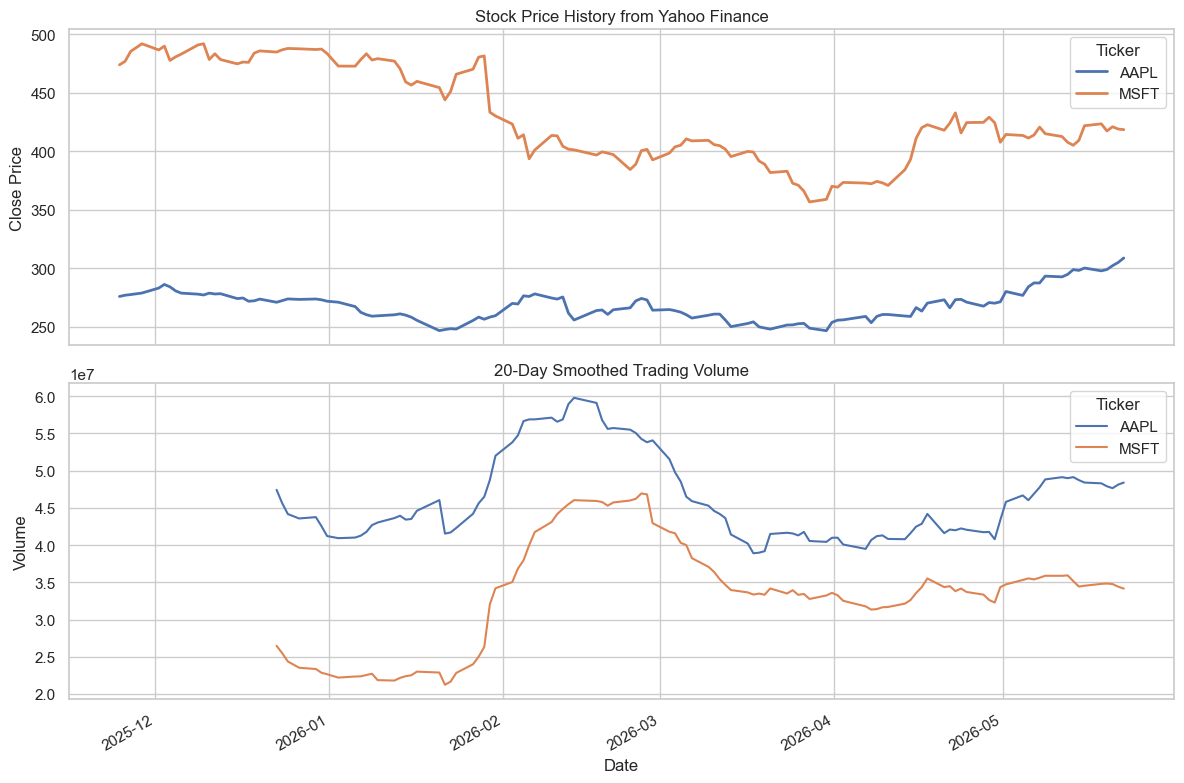

In [8]:
close_prices = stocks.pivot(index="Date", columns="Ticker", values="Close")
volume_data = stocks.pivot(index="Date", columns="Ticker", values="Volume")

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
close_prices.plot(ax=axes[0], linewidth=2)
axes[0].set_title("Stock Price History from Yahoo Finance")
axes[0].set_ylabel("Close Price")
axes[0].legend(title="Ticker")

volume_data.rolling(20).mean().plot(ax=axes[1], linewidth=1.5)
axes[1].set_title("20-Day Smoothed Trading Volume")
axes[1].set_ylabel("Volume")
axes[1].legend(title="Ticker")

fig.tight_layout()
plt.show()

## 3. Exchange rates from a free public API

Exchange rates are another useful way to teach API-based data fetching. Here we use the public Frankfurter API, which exposes historical currency conversion data with no key.

This is a good example of a lightweight JSON API:
- you request a URL with query parameters
- the server returns structured JSON
- you reshape the JSON into a tidy DataFrame before plotting

In [10]:
def fetch_frankfurter_rates(base="USD", currencies=("EUR", "GBP", "JPY"), start_date="2026-04-01", end_date="2026-05-22"):
    url = (
        f"https://api.frankfurter.app/{start_date}..{end_date}"
        f"?from={base}&to={','.join(currencies)}"
    )
    payload = fetch_json(url)
    rows = []
    for date, rates in payload["rates"].items():
        for currency, rate in rates.items():
            rows.append({
                "Date": pd.to_datetime(date),
                "Currency": currency,
                "Rate": rate,
            })
    return pd.DataFrame(rows)


macro = fetch_frankfurter_rates()
display(macro.head())
display(macro.groupby("Currency")["Rate"].agg(["min", "max", "mean"]).round(4))

,Date,Currency,Rate
0,2026-04-01,EUR,0.86170
1,2026-04-01,GBP,0.75065
2,2026-04-01,JPY,158.32000
3,2026-04-02,EUR,0.86768
4,2026-04-02,GBP,0.75708


,min,max,mean
Currency,,,
EUR,0.8477,0.8677,0.8549
GBP,0.7342,0.7571,0.7419
JPY,156.2100,159.8400,158.5646


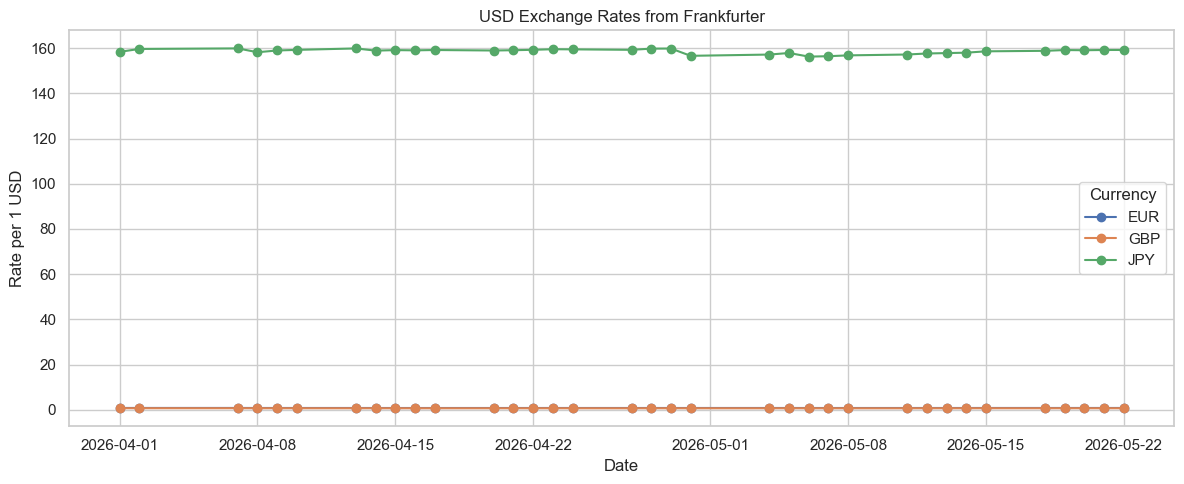

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
for currency, group in macro.groupby("Currency"):
    ax.plot(group["Date"], group["Rate"], marker="o", label=currency)

ax.set_title("USD Exchange Rates from Frankfurter")
ax.set_xlabel("Date")
ax.set_ylabel("Rate per 1 USD")
ax.legend(title="Currency")
fig.tight_layout()
plt.show()

## 4. World Bank API

The World Bank API is another free public source for macro data. It is especially useful for cross-country comparisons.

We will fetch two indicators:
- GDP in current US dollars
- inflation, consumer prices, annual percent

This example shows how a JSON API often returns nested data that needs a little cleaning before plotting.

In [12]:
def fetch_world_bank(indicator, countries=("USA", "CHN"), start_year=2000, end_year=2024):
    country_code = ";".join(countries)
    url = (
        f"https://api.worldbank.org/v2/country/{country_code}/indicator/{indicator}"
        f"?format=json&per_page=20000"
    )
    payload = fetch_json(url)
    records = payload[1]
    rows = []
    for record in records:
        value = record.get("value")
        year = int(record.get("date"))
        if value is None or year < start_year or year > end_year:
            continue
        rows.append({
            "country": record["country"]["value"],
            "year": year,
            "value": float(value),
        })
    return pd.DataFrame(rows)

gdp = fetch_world_bank("NY.GDP.MKTP.CD")
inflation = fetch_world_bank("FP.CPI.TOTL.ZG")

display(gdp.head())
display(inflation.head())

,country,year,value
0,China,2024,1.874380e+13
1,China,2023,1.827036e+13
2,China,2022,1.831677e+13
3,China,2021,1.820170e+13
4,China,2020,1.499641e+13


,country,year,value
0,China,2024,0.218129
1,China,2023,0.234837
2,China,2022,1.973576
3,China,2021,0.981015
4,China,2020,2.419422


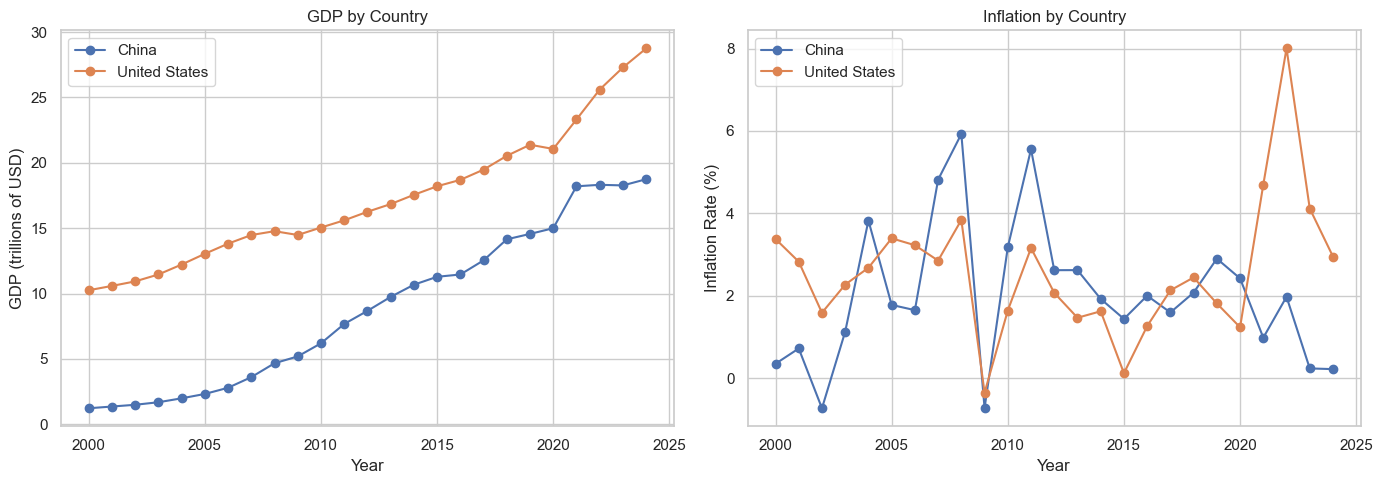

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for country, group in gdp.groupby("country"):
    axes[0].plot(group["year"], group["value"] / 1e12, marker="o", label=country)
axes[0].set_title("GDP by Country")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("GDP (trillions of USD)")
axes[0].legend()

for country, group in inflation.groupby("country"):
    axes[1].plot(group["year"], group["value"], marker="o", label=country)
axes[1].set_title("Inflation by Country")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Inflation Rate (%)")
axes[1].legend()

fig.tight_layout()
plt.show()

## 5. How to choose a free data source

A practical rule is to choose the simplest source that already exposes the data you need.

Guidance:
- use `yfinance` when you want a quick market-data workflow in Python
- use Stooq or another public CSV endpoint when you want no-key examples
- use FRED when you need U.S. macro series
- use the World Bank when you need cross-country macro indicators

Also keep these habits in mind:
- check the source documentation and rate limits
- convert dates to datetime objects immediately
- keep raw downloads and cleaned data in separate files
- save a small sample so your notebook remains reproducible

In [14]:
api_guide = pd.DataFrame([
    {
        "Source": "yfinance",
        "Data Type": "Market data",
        "Access Style": "Python library wrapper",
        "Best For": "Quick stock price pulls",
    },
    {
        "Source": "Yahoo Finance chart API",
        "Data Type": "Market data",
        "Access Style": "Public JSON endpoint",
        "Best For": "No-key stock history examples",
    },
    {
        "Source": "Frankfurter",
        "Data Type": "FX data",
        "Access Style": "Public JSON endpoint",
        "Best For": "Quick exchange-rate examples",
    },
    {
        "Source": "World Bank",
        "Data Type": "Macro data",
        "Access Style": "JSON API",
        "Best For": "Country comparisons",
    },
])

display(api_guide)

output_dir = Path("output")
output_dir.mkdir(exist_ok=True)
stocks.to_csv(output_dir / "yahoo_finance_stock_sample.csv", index=False)
macro.to_csv(output_dir / "exchange_rates_sample.csv", index=False)
gdp.to_csv(output_dir / "world_bank_gdp_sample.csv", index=False)
inflation.to_csv(output_dir / "world_bank_inflation_sample.csv", index=False)
print("Saved cleaned sample files to the output folder.")

,Source,Data Type,Access Style,Best For
0,yfinance,Market data,Python library wrapper,Quick stock price pulls
1,Yahoo Finance chart API,Market data,Public JSON endpoint,No-key stock history examples
2,Frankfurter,FX data,Public JSON endpoint,Quick exchange-rate examples
3,World Bank,Macro data,JSON API,Country comparisons


Saved cleaned sample files to the output folder.


## 6. Next steps

You can extend this notebook by:
- adding more tickers or countries
- merging market and macro data into one analysis table
- building a cache so repeated API calls are faster
- wrapping the fetch code into reusable functions for later notebooks

The main lesson is that good data fetching is about more than making a request. You also need to clean the response, standardize dates, document the source, and save a reproducible copy of the data.